# DMIR × µNAS — Lane-Change Intention on a Microcontroller Budget

**Goal.** Beat the published baseline on the DMIR lane-change tasks (92% accuracy for 3-class intention; 0.42 s / 0.44 s RMSE for LCR / LCL time-to-lane-change) with architectures found by constrained NAS, small enough for STM32 deployment.

**How to use this notebook.**
1. Every code cell is short and calls functions from [`src/`](../src); long logic lives there.
2. **All knobs are in the Configuration cell (§2)** — edit only there, then *Run All*.
3. Each run appends a machine-readable record to `logs/experiments.jsonl` (feeds the paper) and can add a note to `LOGBOOK.md`.
4. After any change to `src/`, run `python scripts/check_pipeline.py` — a 3-task smoke test on real data.

Data facts and known quirks: [`docs/DATA.md`](../docs/DATA.md).

## 1 · Environment

Import the project package and report Python / PyTorch / GPU. Expect `cuda_available: True` on the RTX 5070 (CUDA 12.8 wheels).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.env_utils import env_report, pick_device, seed_everything

device = pick_device()
env_report()

{'python': '3.13.14',
 'platform': 'Windows-11-10.0.26200-SP0',
 'torch': '2.11.0+cu128',
 'cuda_available': True,
 'gpu': 'NVIDIA GeForce RTX 5070 Laptop GPU',
 'gpu_mem_GB': 8.0}

## 2 · Configuration — edit here only

One `Config` object controls the whole pipeline. Key knobs:

| Field | Meaning |
|---|---|
| `task` | `classification`, `regression_lcl`, or `regression_lcr` |
| `subset_fraction` | `1.0` = full data; e.g. `0.05` for a quick smoke run |
| `clip_to_train_range` | clip val/test spikes to the train range (see `docs/DATA.md`) |
| `epochs`, `lr`, `batch_size`, `early_stop_patience` | training schedule |
| `run_name`, `notes` | how this run appears in `logs/experiments.jsonl` |

In [2]:
from src.config import Config

cfg = Config(
    task="classification",      # classification | regression_lcl | regression_lcr
    subset_fraction=1.0,        # 1.0 = full dataset
    clip_to_train_range=True,
    epochs=60,
    batch_size=256,
    lr=3e-3,
    early_stop_patience=10,
    seed=42,
    run_name="baseline-dscnn",
    notes="depthwise-separable CNN baseline",
)
seed_everything(cfg.seed)
cfg

Config(
  task = 'classification'
  seed = 42
  data_dir = 'C:\\Projects\\PhD\\DIMIR\\data'
  clip_to_train_range = True
  subset_fraction = 1.0
  batch_size = 256
  epochs = 60
  lr = 0.003
  weight_decay = 0.0001
  early_stop_patience = 10
  num_workers = 0
  use_amp = True
  run_name = 'baseline-dscnn'
  log_dir = 'C:\\Projects\\PhD\\DIMIR\\logs'
  checkpoint_dir = 'C:\\Projects\\PhD\\DIMIR\\checkpoints'
  notes = 'depthwise-separable CNN baseline'
)

## 3 · Data loading

Loads the prepared pickles for the selected task (float32), clips val/test to the train range if enabled, and reports shapes plus how many cells were clipped.

In [3]:
from src.data import load_task, make_loaders

bundle = load_task(cfg)
print(bundle.summary())

train  x(94620, 50, 31)  y(94620,)  x-range [-183.68, 109.40]
val    x(16332, 50, 31)  y(16332,)  x-range [-110.05, 105.03]
test   x(19722, 50, 31)  y(19722,)  x-range [-117.04, 107.13]
clipped cells -> val: 4507, test: 1037


## 4 · EDA — label distribution

Classification splits are exactly balanced (1/3 per class). Regression targets cover 0.0–4.0 s in 0.1 s steps.

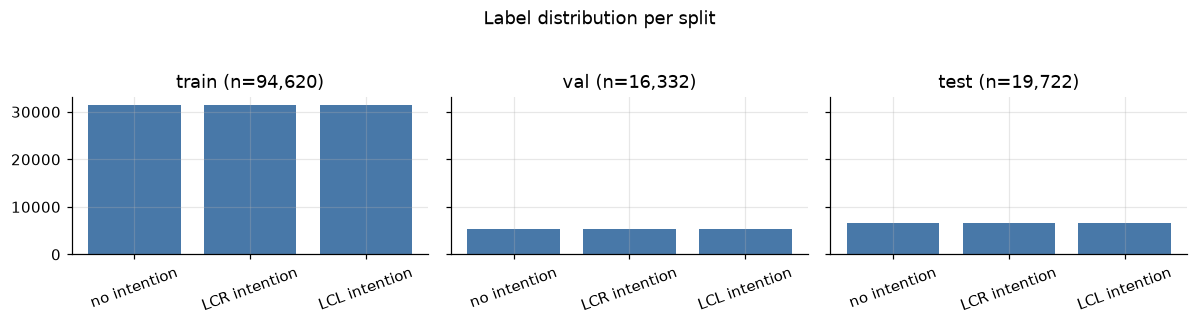

In [4]:
from src import eda

eda.plot_label_distribution(bundle, cfg.is_classification);

## 4.1 · EDA — feature ranges

Per-feature min/max and spread on the training split. Note feature 7 (zero variance in the classification task) and the differing scales across features — the data arrives pre-normalised by the provider, so scales reflect their pipeline.

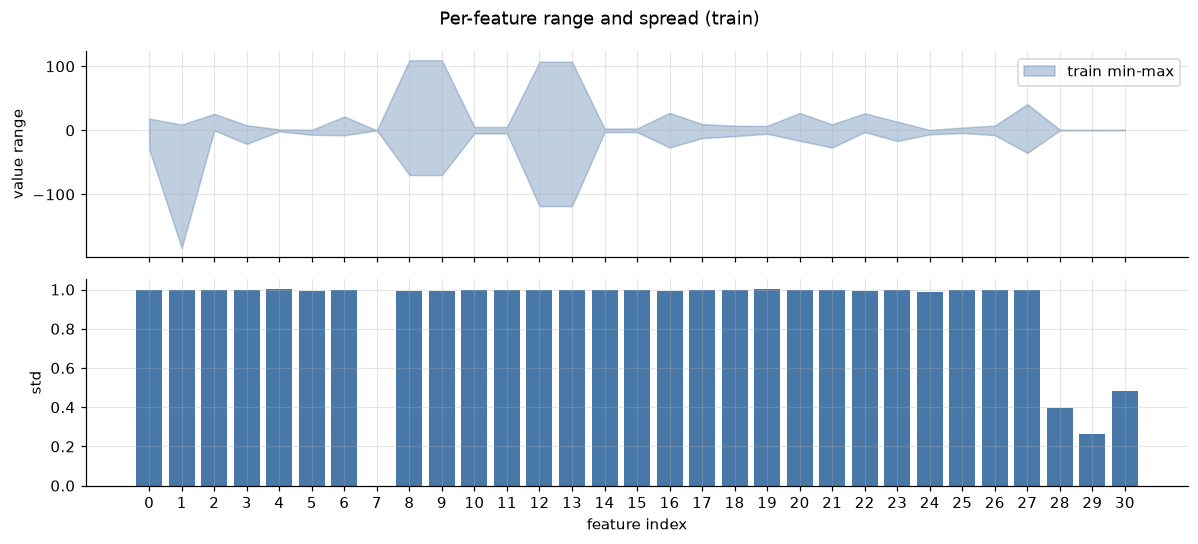

In [5]:
eda.plot_feature_ranges(bundle);

## 4.2 · EDA — example windows

One random 50-timestep training window per class (or per target tercile for regression), showing a few features.

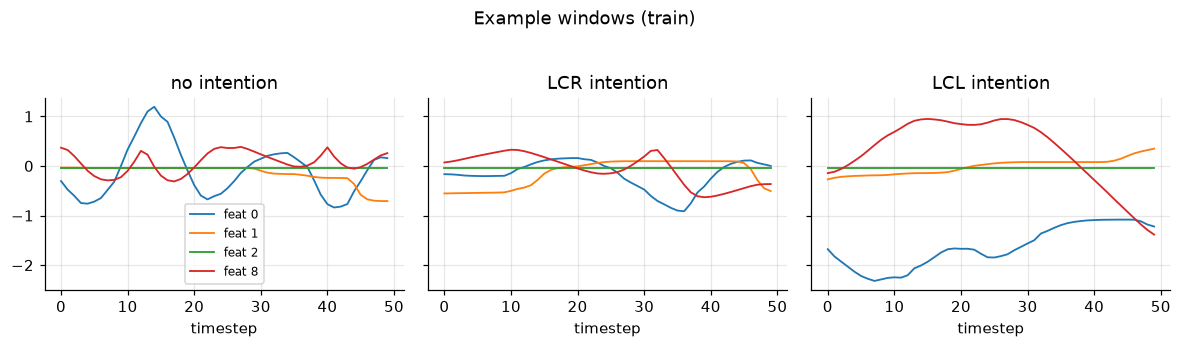

In [6]:
eda.plot_example_windows(bundle, cfg.is_classification, features=(0, 1, 2, 8));

## 5 · Baseline model

Small depthwise-separable 1D CNN (MCU-friendly operator set). This is the internal reference point; NAS (§8) must beat it on the accuracy/footprint trade-off, and the final model must beat the published SOTA.

In [7]:
from torchinfo import summary

from src.models import BaselineDSCNN

model = BaselineDSCNN(n_features=31, n_outputs=cfg.n_outputs)
summary(model, input_size=(1, 31, 50), depth=3)

Layer (type:depth-idx)                   Output Shape              Param #
BaselineDSCNN                            [1, 3]                    --
├─Sequential: 1-1                        [1, 32, 25]               --
│    └─Conv1d: 2-1                       [1, 32, 25]               4,960
│    └─BatchNorm1d: 2-2                  [1, 32, 25]               64
│    └─ReLU: 2-3                         [1, 32, 25]               --
├─Sequential: 1-2                        [1, 64, 7]                --
│    └─DSConvBlock: 2-4                  [1, 48, 13]               --
│    │    └─Sequential: 3-1              [1, 48, 13]               1,792
│    └─DSConvBlock: 2-5                  [1, 64, 7]                --
│    │    └─Sequential: 3-2              [1, 64, 7]                3,440
├─Sequential: 1-3                        [1, 3]                    --
│    └─AdaptiveAvgPool1d: 2-6            [1, 64, 1]                --
│    └─Flatten: 2-7                      [1, 64]                   --
│    └

## 6 · Training

AdamW + cosine schedule, mixed precision on GPU, early stopping on the validation metric (accuracy or RMSE), best weights restored. An `ExperimentLogger` starts recording here and is written to disk in §7.2.

In [8]:
from src.log_utils import ExperimentLogger
from src.train import train_model

loaders = make_loaders(cfg, bundle)
logger = ExperimentLogger(cfg)
history = train_model(cfg, model, loaders, device)

epoch   1/60  train_loss 0.2520  val_loss 0.1688  val_acc 0.9322 *


epoch   2/60  train_loss 0.1655  val_loss 0.1907  val_acc 0.9326 *


epoch   3/60  train_loss 0.1490  val_loss 0.1695  val_acc 0.9465 *


epoch   4/60  train_loss 0.1392  val_loss 0.1959  val_acc 0.9435


epoch   5/60  train_loss 0.1314  val_loss 0.2021  val_acc 0.9416


...

epoch   9/60  train_loss 0.1109  val_loss 0.2739  val_acc 0.9438


epoch  10/60  train_loss 0.1074  val_loss 0.2169  val_acc 0.9394


epoch  11/60  train_loss 0.1059  val_loss 0.2342  val_acc 0.9463


epoch  12/60  train_loss 0.1009  val_loss 0.2444  val_acc 0.9450


epoch  13/60  train_loss 0.0987  val_loss 0.2462  val_acc 0.9399
early stop at epoch 13 (best epoch 3)


## 6.1 · Training curves

Loss and validation metric per epoch; dashed line marks the restored best epoch.

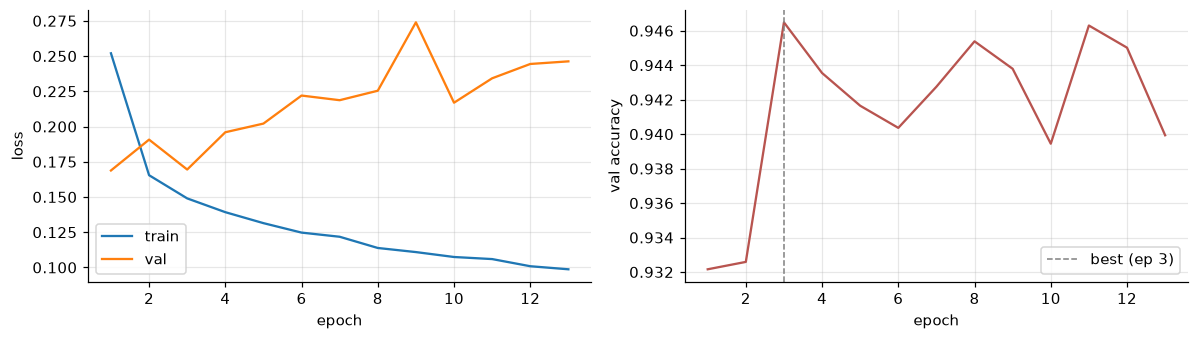

In [9]:
eda.plot_history(history, cfg.is_classification);

## 7 · Test evaluation vs. published SOTA

Targets to beat — classification: **92% accuracy**; regression RMSE: **0.42 s (LCR)** / **0.44 s (LCL)**. For classification a confusion matrix is shown; regression reports RMSE and MAE.

test accuracy: 0.9151   (SOTA 0.92, not beaten yet)
macro-F1: 0.9153   per-class recall: [0.9043, 0.9595, 0.8814]


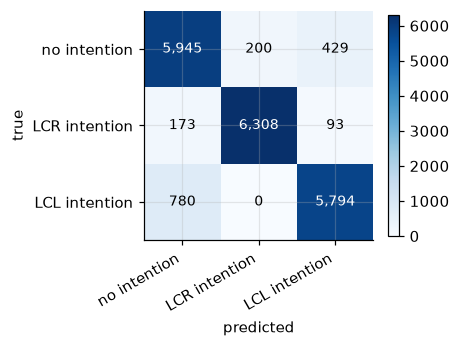

In [10]:
from src.train import evaluate

test = evaluate(cfg, model, loaders["test"], device)
SOTA = {"classification": ("accuracy", 0.92, "higher"),
        "regression_lcl": ("rmse", 0.44, "lower"),
        "regression_lcr": ("rmse", 0.42, "lower")}
key, ref, direction = SOTA[cfg.task]
ours = test[key]
beat = ours > ref if direction == "higher" else ours < ref
print(f"test {key}: {ours:.4f}   (SOTA {ref}, {'BEATEN' if beat else 'not beaten yet'})")
if cfg.is_classification:
    print(f"macro-F1: {test['macro_f1']:.4f}   per-class recall: {test['per_class_recall']}")
    eda.plot_confusion_matrix(test["confusion_matrix"]);
else:
    print(f"MAE: {test['mae']:.4f} s")

## 7.1 · Persist the experiment record

Appends this run (config + environment + metrics + duration) to `logs/experiments.jsonl`. Set `WRITE_LOGBOOK_NOTE = True` to also add a human-readable entry to `LOGBOOK.md`.

In [11]:
from src.log_utils import append_logbook

logger.log_metrics(best_epoch=history["best_epoch"],
                   best_val_metric=history["best_val_metric"],
                   train_time_s=history["train_time_s"],
                   **{f"test_{k}": v for k, v in test.items() if k != "confusion_matrix"})
path = logger.finish()
print(f"logged -> {path}")

WRITE_LOGBOOK_NOTE = False   # set True to journal this run
if WRITE_LOGBOOK_NOTE:
    append_logbook(f"Run {cfg.run_name} ({cfg.task})",
                   f"test {key} = {ours:.4f} (SOTA {ref}). Notes: {cfg.notes}")

logged -> C:\Projects\PhD\DIMIR\logs\experiments.jsonl


## 8 · Constrained NAS (µNAS-style) — next stage

**Status: design in progress.** Planned approach, to be finalised from the research notes in `docs/research/`:

- Search space: 1D CNN cells (depthwise-separable / standard conv, kernel {3,5,7,9}, width, depth, pooling), MCU-friendly ops only.
- Constraints: peak RAM, flash (params after int8), MACs as latency proxy — µNAS-style aging evolution with constraint-aware objective.
- Multi-objective output: accuracy vs. footprint Pareto front (feeds the paper's main figure).

TO-DO before implementation: confirm target MCU (flash/RAM budget) and deployment toolchain metrics from the STM32 research notes.

## 9 · Export for STM32 (ONNX)

Exports the trained model to ONNX — input for the ST Edge AI toolchain (footprint/latency reports, int8 quantisation). Runs a parity check between PyTorch and ONNX Runtime outputs.

In [12]:
import numpy as np
import onnxruntime as ort
import torch

EXPORT = True
if EXPORT:
    out_dir = ROOT / "models" / "exported"
    out_dir.mkdir(parents=True, exist_ok=True)
    onnx_path = out_dir / f"{cfg.run_name}-{cfg.task}.onnx"
    model.eval().cpu()
    example = torch.from_numpy(bundle.x_test[:1]).transpose(1, 2)
    torch.onnx.export(model, (example,), str(onnx_path), input_names=["window"],
                      output_names=["out"], dynamo=False)
    sess = ort.InferenceSession(str(onnx_path))
    ref = model(example).detach().numpy()
    got = sess.run(None, {"window": example.numpy()})[0]
    print(f"exported -> {onnx_path}")
    print(f"PyTorch/ONNX max abs diff: {np.abs(ref - got).max():.2e}")
    model.to(device)

C:\Users\SMoha\AppData\Local\Temp\ipykernel_38520\437214488.py:12: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, (example,), str(onnx_path), input_names=["window"],


exported -> C:\Projects\PhD\DIMIR\models\exported\baseline-dscnn-classification.onnx
PyTorch/ONNX max abs diff: 4.77e-07
